In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np


# Data Visualisation
import matplotlib.pyplot as plt


# Machine Learning Utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV


# Data Preprocessing
from sklearn.preprocessing import LabelEncoder


# Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier)


# Model Evaluation
# These metrics evaluate the classification models from multiple
# perspectives instead of relying only on accuracy.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Model Saving
# Joblib saves the trained machine learning model so it can be
# reused later in the Streamlit web application without retraining.
import joblib


In [2]:
## Read *.csv file into pandas DataFrame
FILE_PATH= "student grade prediction.xlsx"
df = pd.read_excel(FILE_PATH, sheet_name="student-por") ## Read the data from the excel file")
df ## Display dataframe

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [4]:
df.isnull().sum()


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [5]:
print("Numerical Features")
display(df.describe())

print("Categorical Features")
display(df.describe(include="object"))

Numerical Features


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


Categorical Features


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649,649
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,no,yes,yes,yes,no
freq,423,383,452,457,569,258,367,285,455,581,398,610,334,521,580,498,410


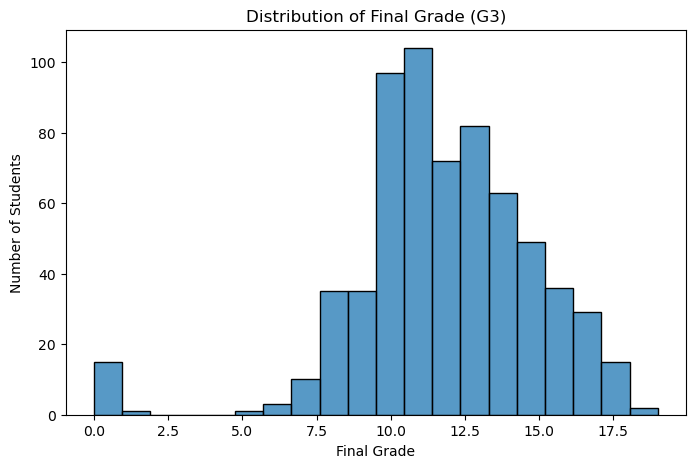

In [6]:
# Display the distribution of the final grade (G3)
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], bins=20)

plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

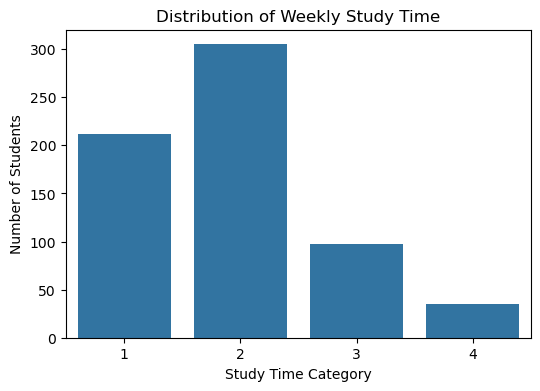

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="studytime", data=df)

plt.title("Distribution of Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

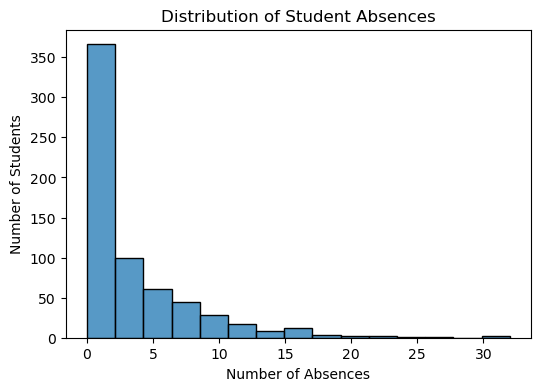

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["absences"], bins=15)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()

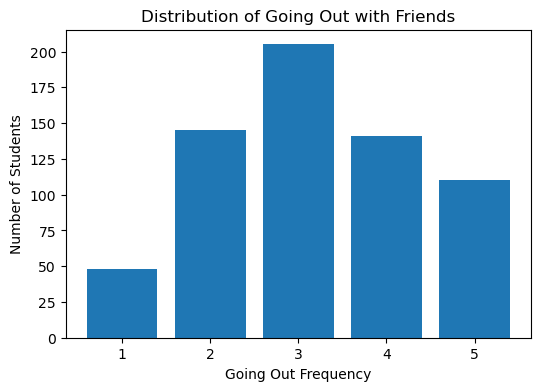

In [9]:
# Distribution of Going Out with Friends

goout_counts = df["goout"].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(goout_counts.index.astype(str), goout_counts.values)

plt.title("Distribution of Going Out with Friends")
plt.xlabel("Going Out Frequency")
plt.ylabel("Number of Students")

plt.show()

In [10]:
# Check for duplicate rows and missing values in the dataset

print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
print(df.isnull().sum())

Duplicate rows: 0
Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [11]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [12]:
# Convert the numerical final grade (G3) into grade categories
def convert_grade(score):
    if score >= 16:
        return "A"
    elif score >= 11:
        return "B"
    elif score >= 6:
        return "C"
    else:
        return "D"

df["Grade"] = df["G3"].apply(convert_grade)

# Check the new target variable
df[["G3", "Grade"]].head()

,G3,Grade
0,11,B
1,11,B
2,12,B
3,14,B
4,13,B


In [13]:
# Display the distribution of the target variable
df["Grade"].value_counts().sort_index()

Grade
A     82
B    370
C    180
D     17
Name: count, dtype: int64

In [14]:
df.drop(columns=["G3"], inplace=True)
df.drop(columns=["G1"], inplace=True)

In [15]:
# Store categorical features (excluding the target)
categorical_features = df.select_dtypes(include="object").drop(columns=["Grade"]).columns

categorical_features
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [16]:
# Convert target labels into integers
grade_mapping = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3
}

df["Grade"] = df["Grade"].map(grade_mapping)

# Display the encoded target values
df["Grade"].value_counts().sort_index()
# Integer encoding is applied to the target variable because
# machine learning classification models require numerical labels.

Grade
0     82
1    370
2    180
3     17
Name: count, dtype: int64

In [17]:
# Separate the features (X) and target variable (y)
X = df.drop(columns=["Grade"])
y = df["Grade"]

In [18]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (519, 40)
X_test: (130, 40)
y_train: (519,)
y_test: (130,)


In [20]:
# # Initialise the Logistic Regression model
logistic_model = LogisticRegression(
     max_iter=1000,
     random_state=42
 )


In [21]:
logistic_model.fit(X_train, y_train)

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [22]:
y_pred_lr = logistic_model.predict(X_test)

In [23]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_lr, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_lr, average="weighted"))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.8538461538461538
Precision: 0.860991182730313
Recall   : 0.8538461538461538
F1-score : 0.855011655011655
              precision    recall  f1-score   support

           0       0.73      0.94      0.82        17
           1       0.91      0.85      0.88        74
           2       0.83      0.83      0.83        36
           3       0.67      0.67      0.67         3

    accuracy                           0.85       130
   macro avg       0.79      0.82      0.80       130
weighted avg       0.86      0.85      0.86       130

[[16  1  0  0]
 [ 6 63  5  0]
 [ 0  5 30  1]
 [ 0  0  1  2]]


In [24]:
# Initialise the Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
y_pred_dt = dt_model.predict(X_test)

In [26]:
# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_dt, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_dt, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_dt))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.7307692307692307
Precision: 0.7339705041255503
Recall   : 0.7307692307692307
F1-score : 0.7290734318985918
              precision    recall  f1-score   support

           0       0.65      0.88      0.75        17
           1       0.78      0.77      0.78        74
           2       0.71      0.61      0.66        36
           3       0.33      0.33      0.33         3

    accuracy                           0.73       130
   macro avg       0.62      0.65      0.63       130
weighted avg       0.73      0.73      0.73       130

[[15  2  0  0]
 [ 8 57  9  0]
 [ 0 12 22  2]
 [ 0  2  0  1]]


In [27]:
# Initialise the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict the testing dataset
y_pred_rf = rf_model.predict(X_test)

# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_rf, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_rf, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_rf))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_rf))


Accuracy : 0.8307692307692308
Precision: 0.8115758330738088
Recall   : 0.8307692307692308
F1-score : 0.8203333333333335
              precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       0.86      0.88      0.87        74
           2       0.79      0.86      0.83        36
           3       0.00      0.00      0.00         3

    accuracy                           0.83       130
   macro avg       0.61      0.61      0.61       130
weighted avg       0.81      0.83      0.82       130

[[12  5  0  0]
 [ 3 65  6  0]
 [ 0  5 31  0]
 [ 0  1  2  0]]


c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\afsh

In [28]:
# Initialise the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predict the testing dataset
y_pred_gb = gb_model.predict(X_test)

# Display evaluation metrics
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_gb, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_gb, average="weighted"))

# Display the classification report
print(classification_report(y_test, y_pred_gb))

# Display the confusion matrix
print(confusion_matrix(y_test, y_pred_gb))


Accuracy : 0.8461538461538461
Precision: 0.8553380087726833
Recall   : 0.8461538461538461
F1-score : 0.8471693823417962
              precision    recall  f1-score   support

           0       0.70      0.94      0.80        17
           1       0.89      0.85      0.87        74
           2       0.85      0.81      0.83        36
           3       1.00      0.67      0.80         3

    accuracy                           0.85       130
   macro avg       0.86      0.82      0.82       130
weighted avg       0.86      0.85      0.85       130

[[16  1  0  0]
 [ 7 63  4  0]
 [ 0  7 29  0]
 [ 0  0  1  2]]


In [29]:
# Create a summary table comparing all models

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, average="weighted"),
        precision_score(y_test, y_pred_dt, average="weighted"),
        precision_score(y_test, y_pred_rf, average="weighted"),
        precision_score(y_test, y_pred_gb, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, average="weighted"),
        recall_score(y_test, y_pred_dt, average="weighted"),
        recall_score(y_test, y_pred_rf, average="weighted"),
        recall_score(y_test, y_pred_gb, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr, average="weighted"),
        f1_score(y_test, y_pred_dt, average="weighted"),
        f1_score(y_test, y_pred_rf, average="weighted"),
        f1_score(y_test, y_pred_gb, average="weighted")
    ]
})

comparison

c:\Users\afshe\comt\envs\mldp\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.853846,0.860991,0.853846,0.855012
1,Decision Tree,0.730769,0.733971,0.730769,0.729073
2,Random Forest,0.830769,0.811576,0.830769,0.820333
3,Gradient Boosting,0.846154,0.855338,0.846154,0.847169
